<a href="https://colab.research.google.com/github/r-oli-m/image_caption_generator/blob/main/image_caption_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Caption Generator
**Model:** BLIP (Bootstrapping Language-Image Pre-training) — fine-tuned on Flickr30k

> Before running: **Runtime → Change runtime type → T4 GPU**

---
### Sections
1. Setup & install
2. Load dataset
3. Load model
4. Train (fine-tune)
5. Evaluate (BLEU scores)
6. Demo (Gradio)

## 1. Setup & Install

In [ ]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
if device == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('⚠️  No GPU found — go to Runtime → Change runtime type → T4 GPU')

Device: cuda
GPU: Tesla T4


In [ ]:
!pip install -q transformers datasets Pillow nltk gradio

## 2. Load Dataset
Flickr30k loads automatically from HuggingFace — no manual download needed.
We use 1,000 images for training and 200 for validation to stay within free Colab limits.

Train: 800 images   Val: 160 images
pixel_values shape: torch.Size([4, 3, 384, 384])
Sample caption: two brown dogs are creating large splashes as they run in a river.


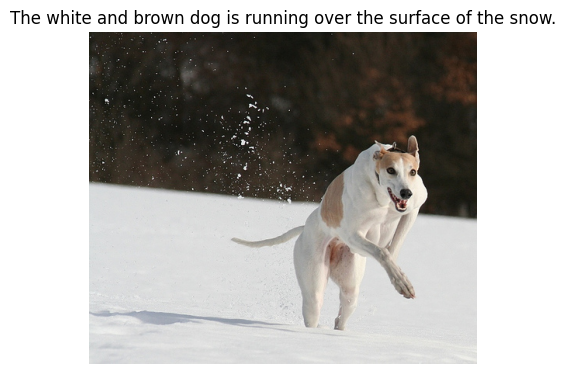

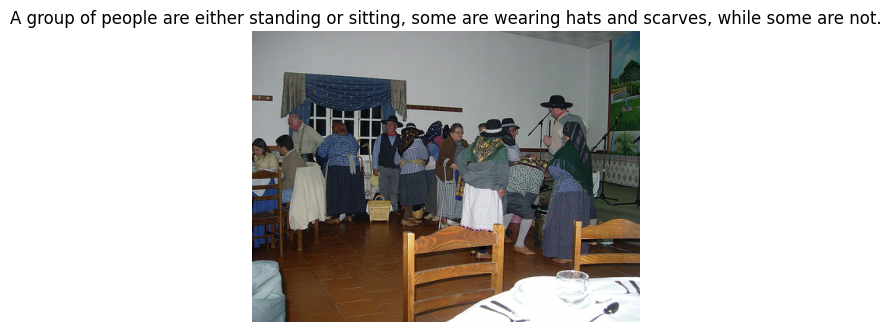

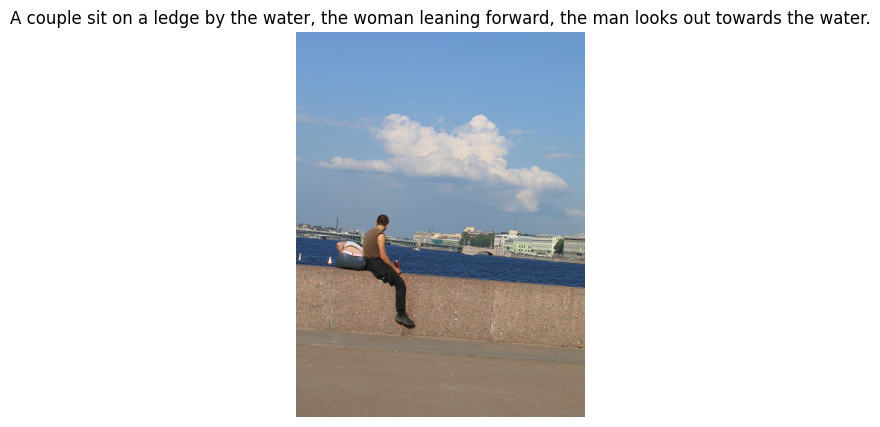

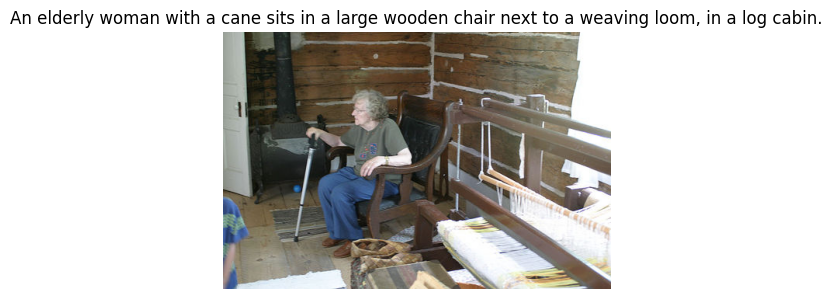

In [ ]:
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from transformers import BlipProcessor
from PIL import Image

# ── Config ────────────────────────────────────────────────────────────────────
MODEL_NAME  = 'Salesforce/blip-image-captioning-base'
TRAIN_SIZE = 800
VAL_SIZE = 160
BATCH_SIZE = 4
EPOCHS = 3
LR = 1e-5
NUM_BEAMS   = 4     # beam search width at inference
SAVE_DIR    = 'blip_finetuned'
MAX_LENGTH = 50

# ── Load raw data ─────────────────────────────────────────────────────────────
print("Downloading Flickr30k...")
raw = load_dataset(
    "nlphuji/flickr30k",
    split="test[:960]", # only using 1200 total images anyway
    revision="refs/convert/parquet"
)
raw = raw.shuffle(seed=42)
train_data = raw.select(range(TRAIN_SIZE))
val_data = raw.select(range(TRAIN_SIZE, TRAIN_SIZE + VAL_SIZE))

print(f"Train: {len(train_data)} images   Val: {len(val_data)} images")

# ── Processor (handles image resizing + tokenization) ─────────────────────────
processor = BlipProcessor.from_pretrained(MODEL_NAME)

# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class FlickrDataset(Dataset):
    def __init__(self, hf_split):
        self.data = hf_split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item['image'].convert('RGB')

        # Flickr30k has 5 captions per image; use the first
        captions = item.get('caption', item.get('captions', ['']))
        caption  = captions[0] if isinstance(captions, list) else captions

        enc = processor(
            images=image, text=caption,
            padding='max_length', truncation=True,
            max_length=MAX_LENGTH, return_tensors='pt'
        )
        pixel_values   = enc['pixel_values'].squeeze(0)
        input_ids      = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)

        labels = input_ids.clone()
        labels[labels == processor.tokenizer.pad_token_id] = -100  # ignore padding in loss

        return {'pixel_values': pixel_values, 'input_ids': input_ids,
                'attention_mask': attention_mask, 'labels': labels}

train_loader = DataLoader(FlickrDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(FlickrDataset(val_data),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Quick sanity check
sample = next(iter(train_loader))
print('pixel_values shape:', sample['pixel_values'].shape)   # [8, 3, 384, 384] [BATCH, CHANNELS, HEIGHT, WIDTH]
print('Sample caption:', processor.tokenizer.decode(sample['input_ids'][0], skip_special_tokens=True))

import matplotlib.pyplot as plt

for i in range(4):
    item = train_data[i]

    plt.figure(figsize=(5,5))
    plt.imshow(item["image"])
    plt.axis("off")
    plt.title(
        item["caption"][0]
        if isinstance(item["caption"], list)
        else item["caption"]
    )
    plt.show()

## 3. Load Model
BLIP-base (~250M parameters). We load the pretrained weights and fine-tune the decoder.

In [ ]:
from transformers import BlipForConditionalGeneration

model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME)
model.to(device)

# Freeze vision encoder
for param in model.vision_model.parameters():
    param.requires_grad = False

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total/1e6:.1f}M')
print(f'Trainable params: {trainable/1e6:.1f}M')

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Total params    : 224.0M
Trainable params: 137.9M


## 4. Train (Fine-tune)
3 epochs on 800 images.
The best checkpoint (lowest val loss) is saved to `blip_finetuned/`.

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.amp import GradScaler, autocast
from tqdm.notebook import tqdm

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=0.01
)

scaler = GradScaler("cuda", enabled=(device == "cuda"))

best_loss = float("inf")
os.makedirs(SAVE_DIR, exist_ok=True)

history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(1, EPOCHS + 1):

    model.train()
    train_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        pv  = batch["pixel_values"].to(device)
        ids = batch["input_ids"].to(device)
        msk = batch["attention_mask"].to(device)
        lbl = batch["labels"].to(device)

        optimizer.zero_grad()

        with autocast("cuda", enabled=(device == "cuda")):
            loss = model(
                pixel_values=pv,
                input_ids=ids,
                attention_mask=msk,
                labels=lbl
            ).loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]"):
            pv  = batch["pixel_values"].to(device)
            ids = batch["input_ids"].to(device)
            msk = batch["attention_mask"].to(device)
            lbl = batch["labels"].to(device)

            with autocast("cuda", enabled=(device == "cuda")):
                loss = model(
                    pixel_values=pv,
                    input_ids=ids,
                    attention_mask=msk,
                    labels=lbl
                ).loss

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)

    print(f"Epoch {epoch}: train loss={avg_train_loss:.4f}, val loss={avg_val_loss:.4f}")

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        model.save_pretrained(SAVE_DIR)
        processor.save_pretrained(SAVE_DIR)
        print(f"✓ Best model saved → {SAVE_DIR}")

print(f"Done! Best val loss: {best_loss:.4f}")

Epoch 1/3 [train]:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1/3 [val]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1: train loss=2.9437, val loss=2.7554


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Best model saved → blip_finetuned


...

Epoch 3/3 [train]:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 3/3 [val]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 3: train loss=1.8479, val loss=2.4187


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Best model saved → blip_finetuned
Done! Best val loss: 2.4187


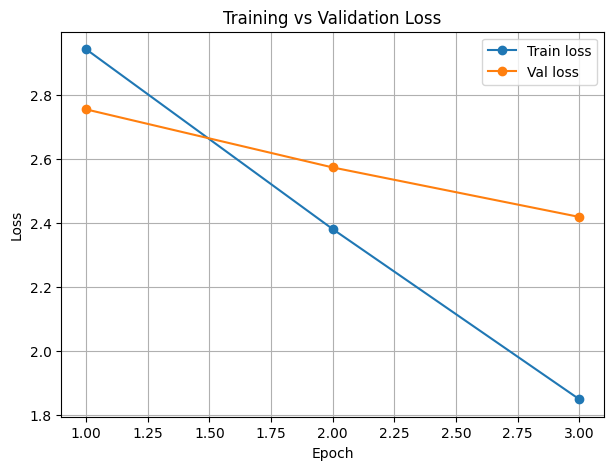

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 5. Evaluate (BLEU Scores)
BLEU measures how closely generated captions match the reference.
We compare the base pretrained model vs. our fine-tuned version.

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def generate_captions(mdl):
    mdl.eval()
    hyps, refs = [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Evaluating'):
            pv  = batch['pixel_values'].to(device)
            lbl = batch['labels']

            out_ids = mdl.generate(pixel_values=pv, num_beams=NUM_BEAMS, max_length=MAX_LENGTH)
            preds   = processor.batch_decode(out_ids, skip_special_tokens=True)

            ref_ids = lbl.clone()
            ref_ids[ref_ids == -100] = processor.tokenizer.pad_token_id
            gts = processor.batch_decode(ref_ids, skip_special_tokens=True)

            for p, g in zip(preds, gts):
                hyps.append(p.lower().split())
                refs.append([g.lower().split()])
    return hyps, refs

def bleu_scores(hyps, refs):
    smooth = SmoothingFunction().method1
    return {f'BLEU-{n}': corpus_bleu(refs, hyps, weights=tuple([1/n]*n), smoothing_function=smooth)
            for n in range(1, 5)}

# ── Base model ────────────────────────────────────────────────────────────────
print('=== Base pretrained model ===')
base_model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)
hyps_base, refs_base = generate_captions(base_model)
for k, v in bleu_scores(hyps_base, refs_base).items():
    print(f'  {k}: {v:.4f}')

# ── Fine-tuned model ──────────────────────────────────────────────────────────
print('\n=== Fine-tuned model ===')
ft_model = BlipForConditionalGeneration.from_pretrained(SAVE_DIR).to(device)
hyps_ft, refs_ft = generate_captions(ft_model)
for k, v in bleu_scores(hyps_ft, refs_ft).items():
    print(f'  {k}: {v:.4f}')


# ── Sample predictions ────────────────────────────────────────────────────────
print('\n── Sample predictions (fine-tuned) ──')
for i in range(5):
    print(f'  Pred : {" ".join(hyps_ft[i])}')
    print(f'  Ref  : {" ".join(refs_ft[i][0])}')
    print()

=== Base pretrained model ===


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

  BLEU-1: 0.1222
  BLEU-2: 0.0714
  BLEU-3: 0.0434
  BLEU-4: 0.0274

=== Fine-tuned model ===


Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

  BLEU-1: 0.3709
  BLEU-2: 0.2252
  BLEU-3: 0.1429
  BLEU-4: 0.0940

── Sample predictions (fine-tuned) ──
  Pred : a man in a black bur is walking with a woman in a black bur
  Ref  : a woman in a long black burqa walks toward a shopping area while a short - haired man with a beard walks beside her.

  Pred : a man wearing a helmet and climbing gear is climbing a rock wall.
  Ref  : a climber wearing a blue helmet and headlamp is attached to a rope on the rock face.

  Pred : a young boy in a red shirt and blue jeans rides a red toy car with a blue handle and a blue propeller.
  Ref  : twin toddlers dressed alike being pushed in plastic car strollers in a parade

  Pred : a woman in a gray tank top and blue jeans is standing in front of a table full of green and red vegetables.
  Ref  : a woman smiles while holding several green peppers at a grocery stand.

  Pred : a man in a white shirt is sitting at a table with food in front of him.
  Ref  : a bald white man wearing an apron dines

## 6. Demo (Gradio)
Load fine-tuned model (or swap SAVE_DIR for MODEL_NAME to use base).
Upload any image → get a caption. The public link is valid for 72 hours.

In [ ]:
import gradio as gr
from PIL import Image as PILImage

# Load fine-tuned model (or swap SAVE_DIR for MODEL_NAME to use base)
demo_model = BlipForConditionalGeneration.from_pretrained(SAVE_DIR).to(device)
demo_model.eval()

def caption(image):
    if image is None:
        return 'Please upload an image.'
    img = PILImage.fromarray(image).convert('RGB')
    inputs = processor(images=img, return_tensors='pt').to(device)
    with torch.no_grad():
        out = demo_model.generate(**inputs, num_beams=NUM_BEAMS, max_length=MAX_LENGTH)
    return processor.decode(out[0], skip_special_tokens=True)

gr.Interface(
    fn=caption,
    inputs=gr.Image(label='Upload an image'),
    outputs=gr.Textbox(label='Generated Caption'),
    title='🖼️ Image Caption Generator',
    description='Powered by BLIP fine-tuned on Flickr30k.',
    theme=gr.themes.Soft(),
).launch(share=True)  # share=True gives a public URL

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b0207bc04f1e9904a8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


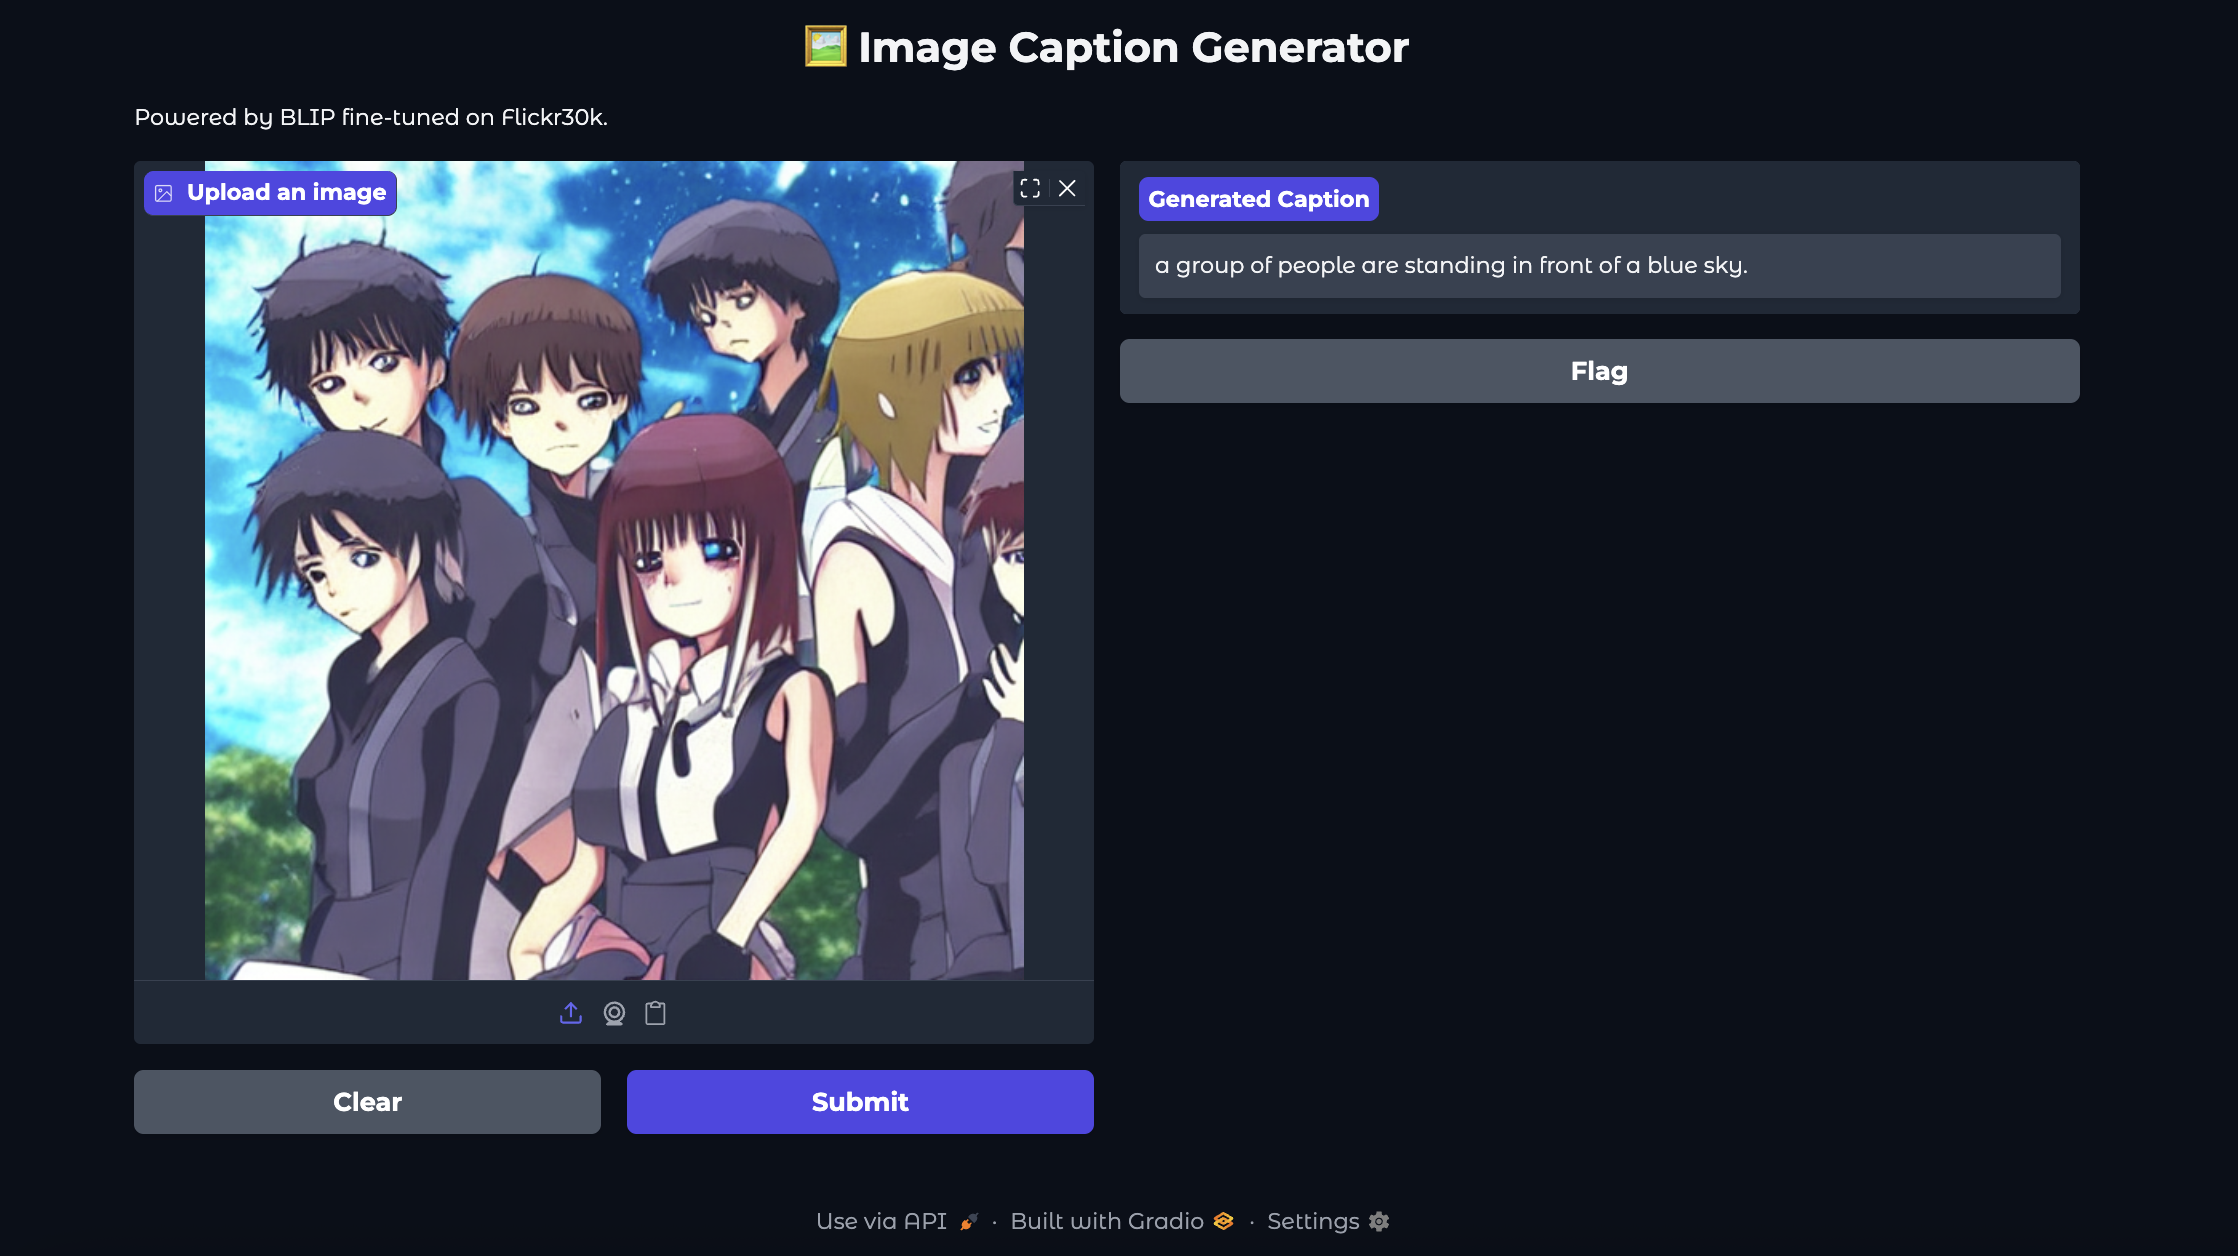